# 1 Installed Quandl Library

# 2 Using bitcoin historical dataset from https://github.com/DataMinati/Datasets-/blob/master/Bitcoin%20Historical%20Data.csv

# Import libraries

In [4]:
import quandl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")

plt.style.use('fivethirtyeight')

In [5]:
# Create path
path = r'C:\Users\shaiv\Downloads\Victoria Airbnb Analysis'

In [6]:
# Importing dataset
bitcoin = pd.read_csv(os.path.join(path,'02 Data', 'Original Data', 'Bitcoin Historical Data.csv'))

In [7]:
# Display all columns
pd.set_option('display.max_columns', None)

In [8]:
# Displaying 5 rows
bitcoin.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,"Aug 02, 2020","11,105.8","11,802.6","12,061.1","10,730.7",698.62K,-5.91%
1,"Aug 01, 2020","11,803.1","11,333.2","11,847.7","11,226.1",611.47K,4.14%
2,"Jul 31, 2020","11,333.4","11,096.5","11,434.8","10,964.6",530.95K,2.14%
3,"Jul 30, 2020","11,096.2","11,105.8","11,164.4","10,861.6",501.14K,-0.09%
4,"Jul 29, 2020","11,105.9","10,908.4","11,336.5","10,771.8",576.83K,1.81%


In [9]:
# Check shape
bitcoin.shape

(3669, 7)

In [10]:
# List of all columns
bitcoin.columns

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')

# 3 Subsetting, wrangling and cleaning time-series data

In [56]:
# Keep only 'Date' and 'Price', remove missing values
bit_data = bitcoin[['Date', 'Price']]
bit_data.dropna(inplace=True)

In [58]:
# Clean 'Price' column: remove commas and convert to float
bit_data['Price'] = bit_data['Price'].str.replace(',', '').astype(float)

In [60]:
# Check for duplicates
bit_data.duplicated().sum()

0

##### There are no duplicates

In [14]:
# Check for null values
bit_data.isnull().sum()

Date     0
Price    0
dtype: int64

##### There are no null values.

In [62]:
# Converting host_since to datetime data type
bit_data['Date'] = pd.to_datetime(bit_data['Date'])

In [64]:
# Sort by date
bit_data.sort_values('Date', inplace=True)

In [66]:
# Reset index and then set 'Date' as index
bit_data.set_index('Date', inplace=True)

# 4 Plotting the line chart

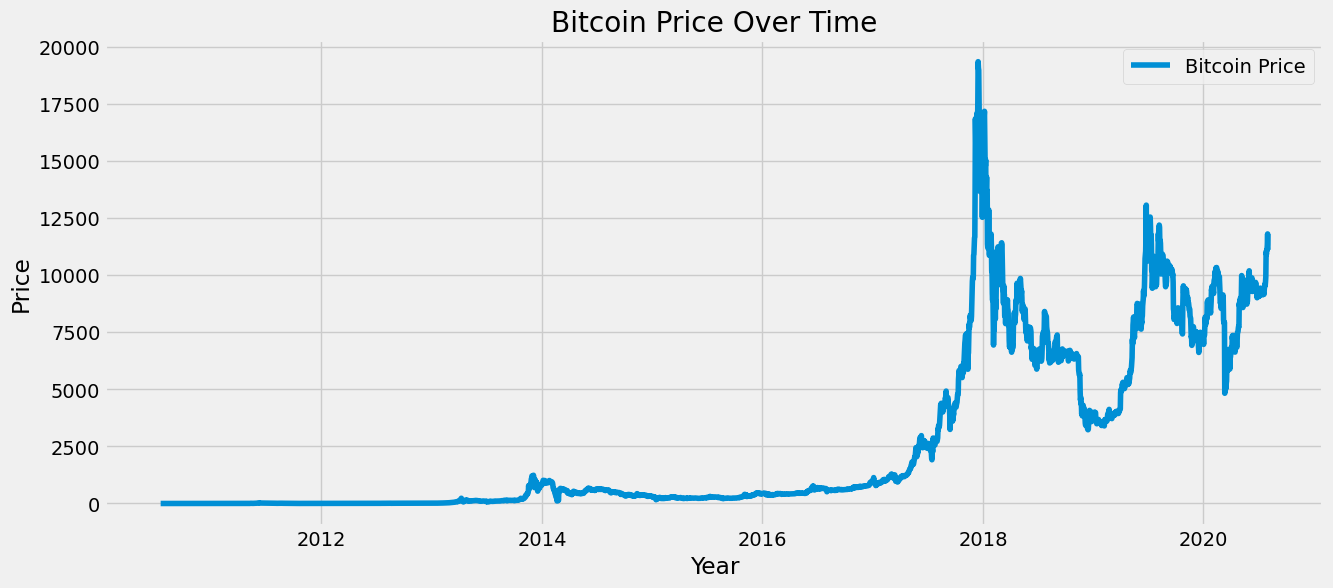

In [68]:
plt.figure(figsize=(14, 6), dpi=100)
plt.plot(bit_data['Price'], label='Bitcoin Price')
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Bitcoin Price Over Time')
plt.legend()
plt.grid(True)
plt.show()

# 5 Decomposing the data components

In [79]:
decomposition = sm.tsa.seasonal_decompose(bit_data, model = 'additive', period = 1)

In [81]:
# Defining fixed size for all charts
from pylab import rcParams
rcParams['figure.figsize'] = 18, 7

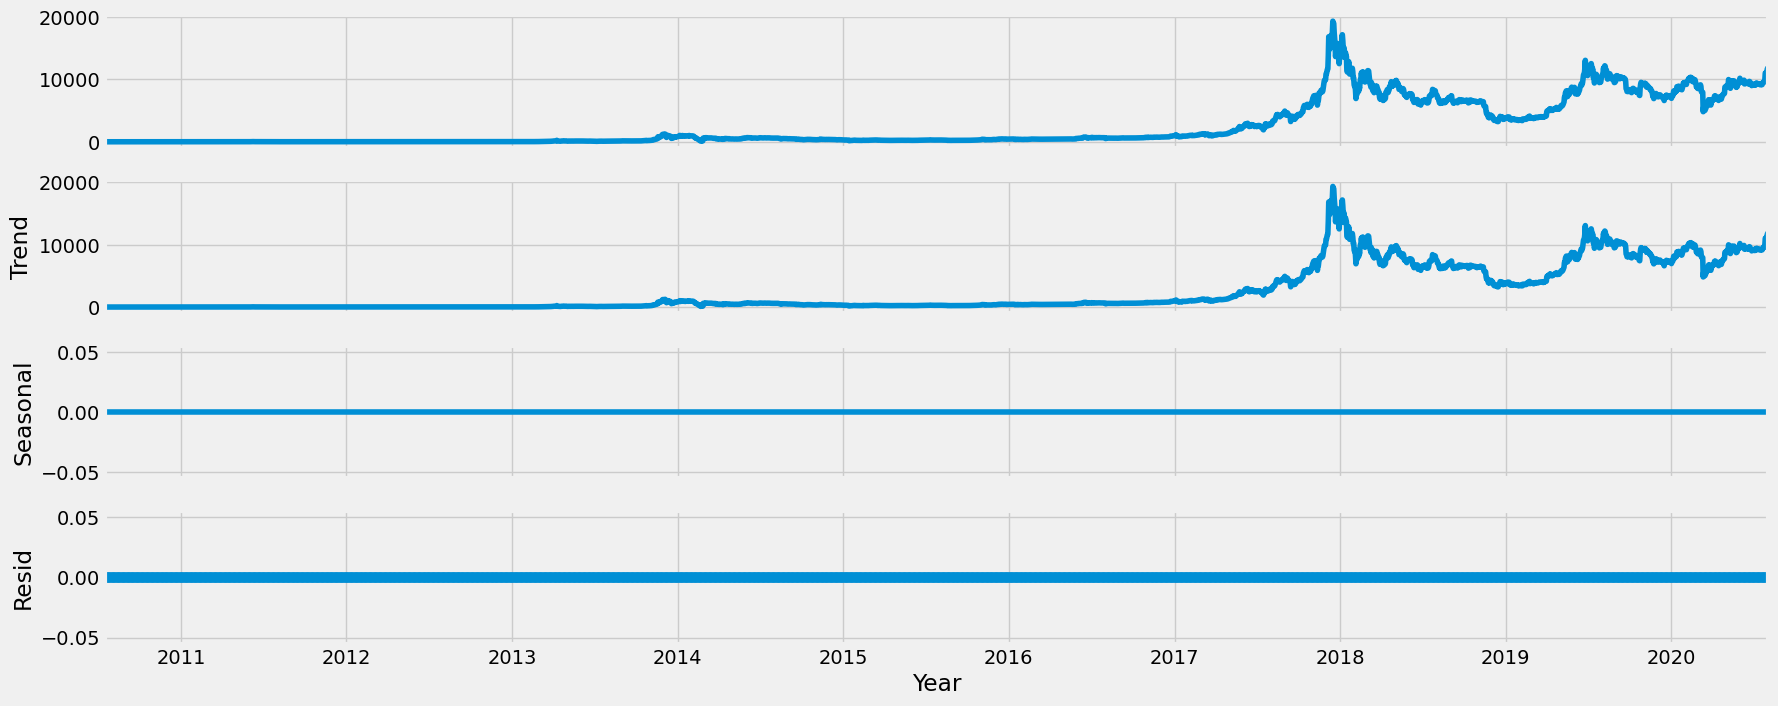

In [83]:
# Plotting the separate components
decomposition.plot()
plt.xlabel('Year')
plt.show()

##### A time series decomposition of Bitcoin prices from 2010 to 2020 reveals a strong upward trend, reflecting long-term growth driven by adoption, exchange development, and institutional interest. The seasonal component is negligible, indicating the absence of consistent periodic patterns typical in traditional markets. This aligns with the cryptocurrency market's dependence on macroeconomic and speculative factors rather than seasonal cycles. The residuals show high volatility, capturing unpredictable short-term movements driven by news and sentiment. Overall, the series is trend-dominated with minimal seasonality and significant noise. Formal statistical testing would be required to confirm if the series is truly non-stationary.

# 6 Dickey-Fuller test to check for stationarity

In [89]:
from statsmodels.tsa.stattools import adfuller 

def dickey_fuller(timeseries): 
    print ('Dickey-Fuller Stationarity test:')
    test = adfuller(timeseries, autolag='AIC')
    result = pd.Series(test[0:4], index=['Test Statistic','p-value','Number of Lags Used','Number of Observations Used'])
    for key,value in test[4].items():
       result['Critical Value (%s)'%key] = value
    print (result)

dickey_fuller(bit_data['Price'])

Dickey-Fuller Stationarity test:
Test Statistic                   -1.221472
p-value                           0.664292
Number of Lags Used              30.000000
Number of Observations Used    3638.000000
Critical Value (1%)              -3.432149
Critical Value (5%)              -2.862335
Critical Value (10%)             -2.567193
dtype: float64


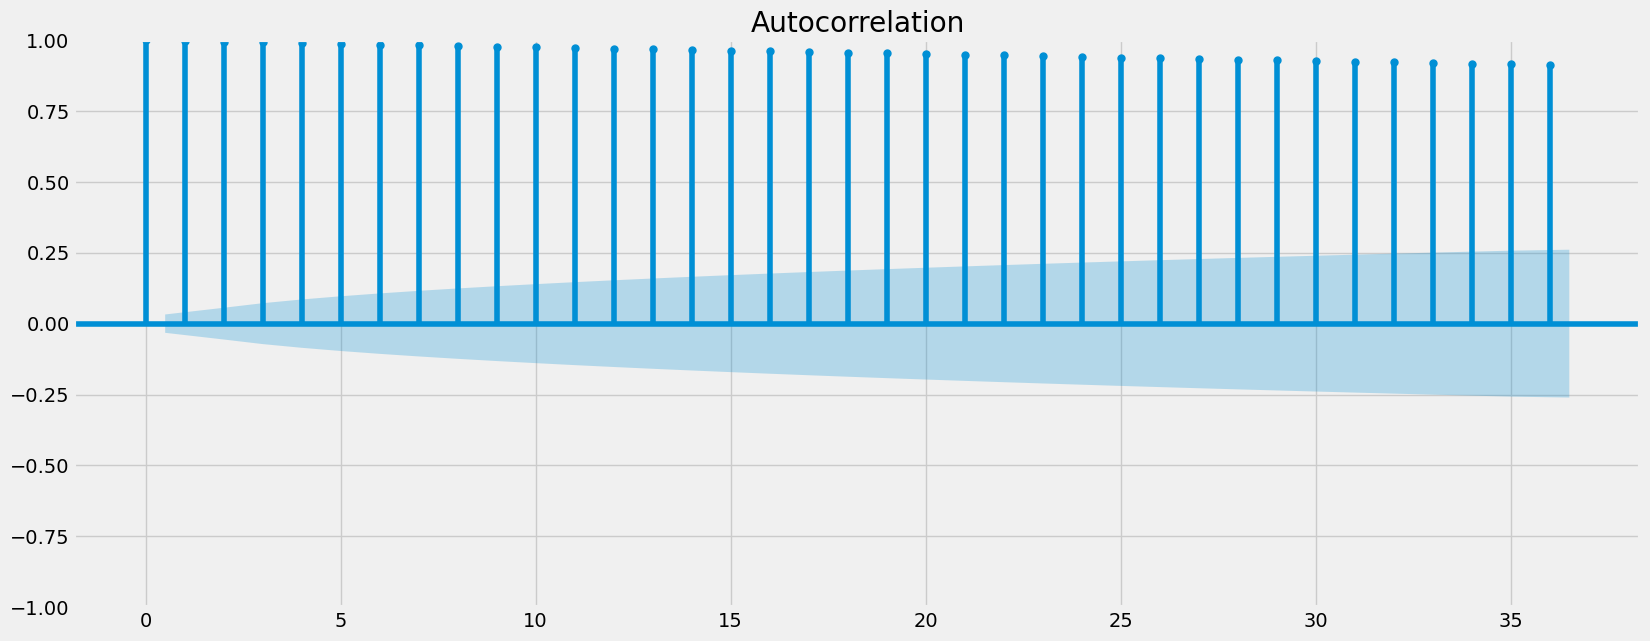

In [91]:
# Plotting for autocorrelations
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(bit_data)
plt.show()

##### The plot shows persistent positive autocorrelation, indicating strong trend behavior and suggesting non-stationarity.

# 7 Creating differenciated time series

In [95]:
bit_diff = bit_data - bit_data.shift(1)

In [97]:
bit_diff.dropna(inplace = True)

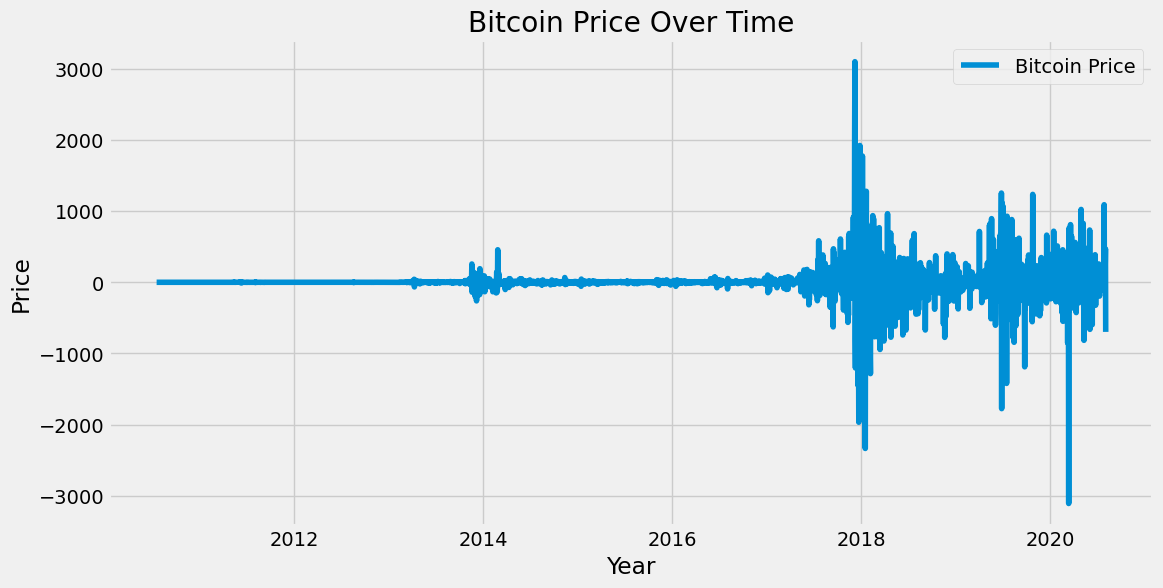

In [101]:
# Plotting the differences
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(bit_diff['Price'], label='Bitcoin Price')
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Bitcoin Price Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [103]:
# Re-performing Dicky-Fuller Stationarity Test
dickey_fuller(bit_diff)

Dickey-Fuller Stationarity test:
Test Statistic                -1.085425e+01
p-value                        1.501647e-19
Number of Lags Used            2.900000e+01
Number of Observations Used    3.638000e+03
Critical Value (1%)           -3.432149e+00
Critical Value (5%)           -2.862335e+00
Critical Value (10%)          -2.567193e+00
dtype: float64


##### After first differencing the Bitcoin price data, the Dickey-Fuller test confirmed stationarity with a p-value close to zero and a test statistic well below critical values.

# 9 Plotting for autocorrelations

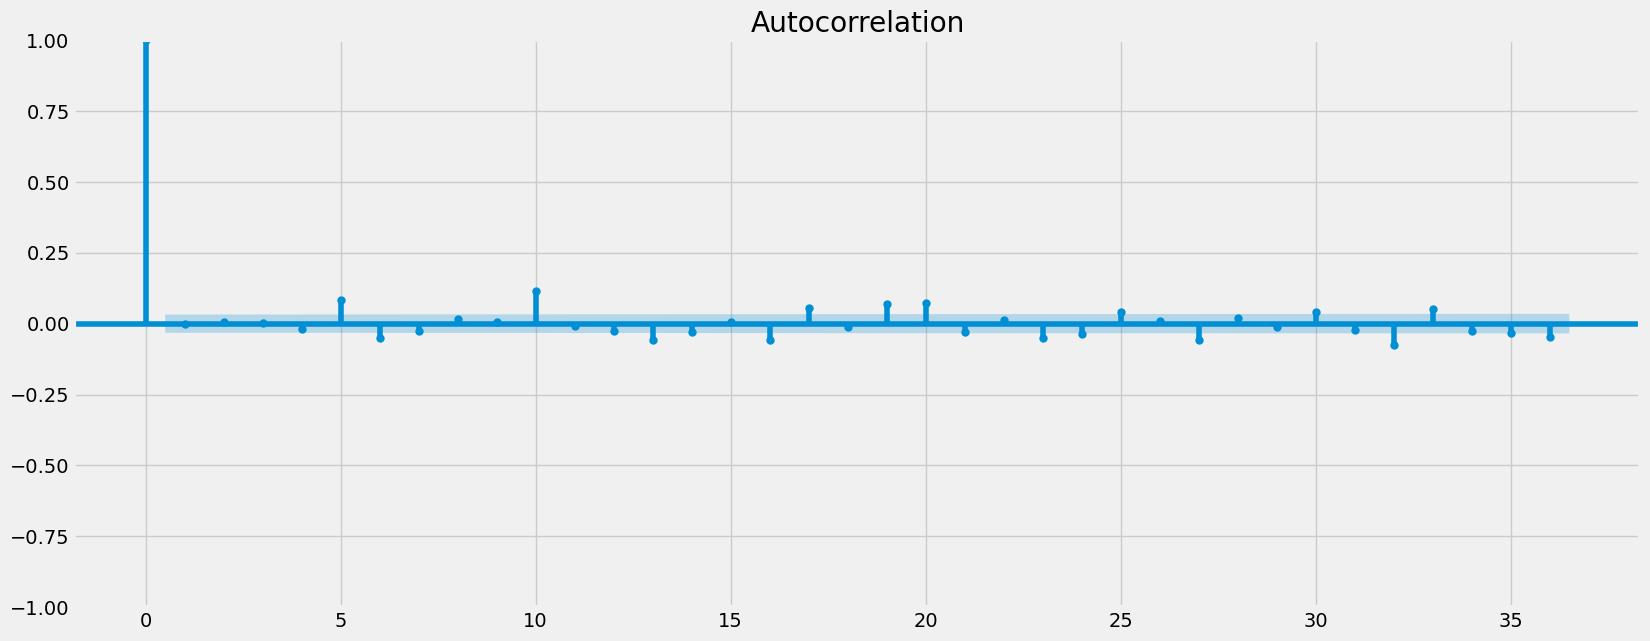

In [108]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(bit_diff)
plt.show()

##### There is no autocorrelation in our time series. We can say that our time series is stationary.